# Action client node

## Imports

In [1]:
from assignment_2_2024.msg import PlanningAction, PlanningGoal

import rospy
import actionlib
import ipywidgets as widgets

from nav_msgs.msg import Odometry
from ass2_ros1.msg import RobotVelocity


In [2]:
%matplotlib widget

import matplotlib.pyplot as plt
import tf

from tf.transformations import quaternion_matrix 
import numpy as np
from matplotlib.animation import FuncAnimation


## Globals


In [3]:
client = None
goal = None
latest_feedback = None

active_goal = False
reached_goals = 0
not_reached_goals = 0

vel_pub = None

In [4]:
def read_feedback(feedback):
    global target_reached, active_goal, latest_feedback
    latest_feedback = feedback

    if (active_goal and feedback.stat == 'Target reached!'):
        rospy.print("Target reached !")
        reached_goals = reached_goals + 1
        active_goal = False
        goal = None

In [5]:
def cancel_goal():
    global client, not_reached_goals, active_goal
    client.cancel_goal
    not_reached_goals = not_reached_goals + 1
    goal = None
    active_goal = False

In [6]:
def publish_robot_velocity(msg):
    vel = RobotVelocity()
    vel.x = msg.pose.pose.position.x
    vel.y = msg.pose.pose.position.y
    vel.vel_x = msg.twist.twist.linear.x
    vel.vel_z = msg.twist.twist.angular.z

    vel_pub.publish(vel)

In [7]:
def update_goal(x, y):
    global goal, active_goal, not_reached_goals
    goal = PlanningGoal()
    
    if active_goal:
        not_reached_goals = not_reached_goals + 1
    else:
        active_goal = True

    goal.target_pose.header.frame_id = "map"
    goal.target_pose.pose.position.x = x
    goal.target_pose.pose.position.y = y
    
    print("new goal set!")
    client.send_goal(goal, feedback_cb=read_feedback)

In [8]:
def print_status():
    if (not goal):
        print("No goal set yet")
        return 
    
    print(goal)
    
    if (not latest_feedback):
        print("No feedacks received from the server yet!")
        return
    print(latest_feedback)

In [9]:
def get_choiche(prompt, choice_list):
    user_input = 0
    input_ok = False

    while not input_ok:
        print(prompt)
        for i, choice in enumerate(choice_list):
            print(f"{i+1}. {choice}")
        
        try:
            user_input = int(input("> ")) - 1
            if user_input >=0 and user_input < len(choice_list):
                input_ok = True
        except:
            pass
        else:
            input_ok = True
        
        if not input_ok:
            print(f"Please input a valid integer between {1} and {len(choice_list)}!")
    
    return user_input

In [10]:
# rospy.sleep(2)
# global client, vel_pub

# rospy.init_node('action_client')

# vel_pub = rospy.Publisher("/robot_status", RobotVelocity, queue_size = 10)
# rospy.Subscriber("/odom", Odometry, publish_robot_velocity)

# client = actionlib.SimpleActionClient('/reaching_goal', PlanningAction)

# choices = {"New/Update goal": update_goal, "Get status": print_status, "Quit": exit}
# choice_list = list(choices.keys())

# rate = rospy.Rate(10)
# while True:
#     choice = get_choiche("Select what you want to do: ", choice_list)
#     choices[choice_list[choice]]()
#     rate.sleep()


In [11]:
rospy.init_node('action_client')
client = actionlib.SimpleActionClient('/reaching_goal', PlanningAction)

# input for new goal
fin_goal_x = widgets.FloatText(value=1,description='X coordinate of target:')
fin_goal_y = widgets.FloatText(value=1,description='Y coordinate of targe:')
btn_new_goal = widgets.Button(description = "Set new Goal", button_style='success')
btn_new_goal.on_click(lambda _: update_goal(fin_goal_x.value, fin_goal_y.value))

# cancel goal
btn_cancel_goal = widgets.Button(description = "Cancel Goal", button_style='danger')
btn_cancel_goal.on_click(lambda _: cancel_goal())

# print status
btn_print_status = widgets.Button(description = "Print Status", button_style='info')
btn_print_status.on_click(lambda _: print_status())

# display
display(fin_goal_x)
display(fin_goal_y)
display(btn_new_goal)
display(btn_cancel_goal)
display(btn_print_status)




FloatText(value=1.0, description='X coordinate of target:')

FloatText(value=1.0, description='Y coordinate of targe:')

Button(button_style='success', description='Set new Goal', style=ButtonStyle())

Button(button_style='danger', description='Cancel Goal', style=ButtonStyle())

Button(button_style='info', description='Print Status', style=ButtonStyle())

new goal set!
new goal set!
target_pose: 
  header: 
    seq: 0
    stamp: 
      secs: 0
      nsecs:         0
    frame_id: "map"
  pose: 
    position: 
      x: 3.0
      y: 1.0
      z: 0.0
    orientation: 
      x: 0.0
      y: 0.0
      z: 0.0
      w: 0.0
No feedacks received from the server yet!


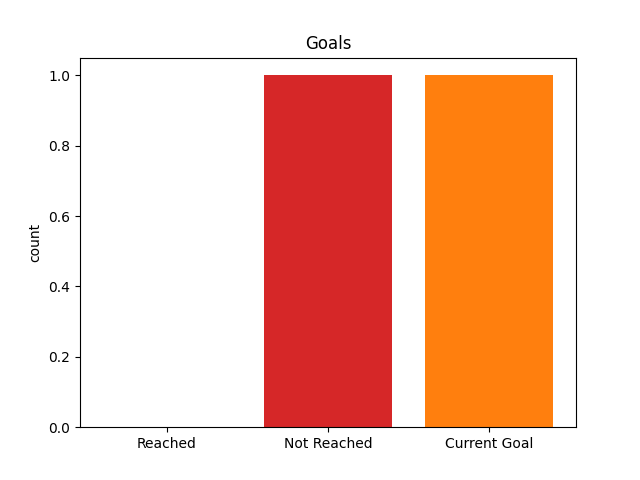

In [14]:
fig, ax = plt.subplots()

x = ['Reached', 'Not Reached', 'Current Goal']
y = [reached_goals, not_reached_goals, 1 if active_goal else 0]

bar_colors = ['tab:green', 'tab:red', 'tab:orange']

ax.bar(x, y, color=bar_colors)
ax.set_ylabel('count')
ax.set_title('Goals')
plt.show()